In [1]:
from data_utils import *
from import_pkgs import *

In [2]:
Bangkok_lon = (99.5,101.5)
Bangkok_lat = (13,15)

def normalize_lon(lon):
    return ((lon + 180) % 360) - 180

gcas_dir = Path(gcas_path)
Bangkok_dates = []

for f in sorted(gcas_dir.glob("asiaaq-GCAS-NO2_LaRC-G3_2024*_R1.nc")):
    ds = xr.open_dataset(f)

    lon = normalize_lon(ds["lon"].values)
    lat = ds["lat"].values
    no2 = ds["no2_vertical_column_below_aircraft"].values
    cloud = ds["cloud_glint_flag"].values

    mask = (
        np.isfinite(lon) &
        np.isfinite(lat) &
        np.isfinite(no2) &
        (cloud == 0) &
        (lon >= Bangkok_lon[0]) & (lon <= Bangkok_lon[1]) &
        (lat >= Bangkok_lat[0]) & (lat <= Bangkok_lat[1])
    )

    if np.any(mask):
        date_str = f.name.split("_")[2]
        Bangkok_dates.append(date_str)

    ds.close()

print(Bangkok_dates)

['20240318', '20240319', '20240321', '20240323', '20240325']


In [3]:
city='Bangkok'
ctrl_matchups,test_matchups,rural_matchups=ctrl_bangkok_matchups,test_bangkok_matchups,rural_bangkok_matchups
target_date = eval(f'{city}_dates')[0]
target_file = gcas_path+f"asiaaq-GCAS-NO2_LaRC-G3_{target_date}_R1.nc"

ctrl_matchups_day = ctrl_matchups[ctrl_matchups["source_file"] == f"asiaaq-GCAS-NO2_LaRC-G3_{target_date}_R1.nc"].copy()
test_matchups_day = test_matchups[test_matchups["source_file"] == f"asiaaq-GCAS-NO2_LaRC-G3_{target_date}_R1.nc"].copy()
rural_matchups_day = rural_matchups[rural_matchups["source_file"] == f"asiaaq-GCAS-NO2_LaRC-G3_{target_date}_R1.nc"].copy()

ctrl_cell_mean = (
    ctrl_matchups_day.groupby("model_ncol_index", as_index=False)["model_no2_1e15_molec_cm2"]
    .mean()
)
rural_cell_mean = (
    rural_matchups_day.groupby("model_ncol_index", as_index=False)["model_no2_1e15_molec_cm2"]
    .mean()
)
test_cell_mean = (
    test_matchups_day.groupby("model_ncol_index", as_index=False)["model_no2_1e15_molec_cm2"]
    .mean()
)

/glade/work/yifanc17/01_scripts/05_urban_AQ_MUSICA/data_utils.py:414: RuntimeWarning: Mean of empty slice
  track_lon = np.nanmean(swath_masked_lon, axis=1)
/glade/work/yifanc17/01_scripts/05_urban_AQ_MUSICA/data_utils.py:415: RuntimeWarning: Mean of empty slice
  track_lat = np.nanmean(swath_masked_lat, axis=1)


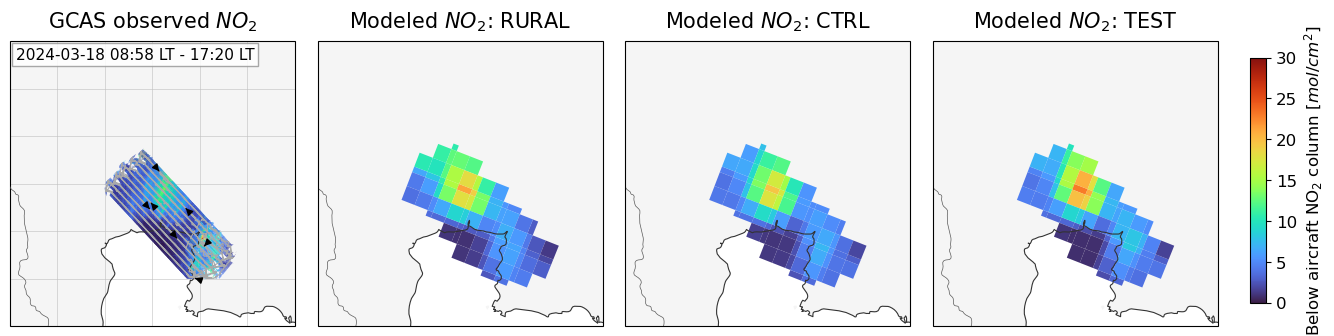

In [4]:
fig, axs = plt.subplots(
    1, 4, figsize=(16, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

vmin=0
vmax=30
# region to plot, focused on bangkok
Thailand_lon_bounds=[99,102]
Thailand_lat_bounds=[12.5,15.5]


Thailand_extent=[Thailand_lon_bounds[0],Thailand_lon_bounds[1],Thailand_lat_bounds[0],Thailand_lat_bounds[1]]
_,_,_,_,_=plot_gcas_swath_map(
    gcas_path+f"asiaaq-GCAS-NO2_LaRC-G3_{target_date}_R1.nc",
    lat_bounds=[13,15],
    lon_bounds=[99.5,101.5],
    ax=axs[0],
    title=r"GCAS observed $NO_2$",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
)
axs[0].set_extent(Thailand_extent, crs=ccrs.PlateCarree())

plot_model_native_grid(rural_cell_mean, Thailand_extent, r"Modeled $NO_2$: RURAL", vmin,vmax, axs[1])

plot_model_native_grid(ctrl_cell_mean, Thailand_extent, r"Modeled $NO_2$: CTRL", vmin,vmax, axs[2])

_,_,pc=plot_model_native_grid(test_cell_mean, Thailand_extent, r"Modeled $NO_2$: TEST", vmin,vmax, axs[3])

plt.subplots_adjust(right=0.88, wspace=0.08)

height = 0.35
bottom = (1 - height) / 2
cax = fig.add_axes([0.90, bottom, 0.010, height])

cb = fig.colorbar(
    pc,              
    cax=cax,
    orientation="vertical",
    pad=0.02,
    shrink=0.8
)

cb.set_label(r"Below aircraft NO$_2$ column [$mol/cm^2$]",fontsize=12)
cb.ax.tick_params(labelsize=12)